# Missing-Data Imputation Comparison


This notebook compares three imputation strategies on the same artificially-masked
dataset, so the comparison is fair:

1. **KNN + KMeans** (fixed k = 3, column-wise clustering)
2. **KNN + Agglomerative Clustering** (fixed k = 3, column-wise clustering)
3. **KNN + KMeans with elbow-selected k** (per-feature optimal k)
4. **Iterative SVD/PCA imputation**



## 1. Imports

In [26]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set(style="whitegrid", palette="tab10")


## 2. Configuration
Edit these once instead of hunting through the notebook.

In [27]:
DATA_PATH = r"C:\Users\USER\Desktop\Aims_Thesis\data\Dataset_scenario_3.csv"
FEATURES = ["Temperature", "Humidity", "Rssi", "Soil_humidity"]

MISSING_RATE = 0.20
RANDOM_STATE = 42

N_CLUSTERS_FIXED = 3          # used by the two fixed-k clustering methods
KNN_NEIGHBORS_INITIAL = 5     # global warm-start imputation
KNN_NEIGHBORS_CLUSTERWISE = 3 # imputation inside each cluster

SVD_VARIANCE_THRESHOLD = 0.85
SVD_MAX_ITER = 20
SVD_TOL = 1e-4

# Where to save output figures/tables (set to None to skip saving)
OUTPUT_DIR = "charts"


## 3. Load data

In [28]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Update DATA_PATH in the config cell above."
    )

if OUTPUT_DIR:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

raw_data = pd.read_csv(DATA_PATH)
original_data = raw_data[FEATURES].copy()
data_numeric = original_data.select_dtypes(include=[np.number])

print(f"Loaded {len(original_data)} rows, {len(FEATURES)} features: {FEATURES}")
original_data.head()


Loaded 192 rows, 4 features: ['Temperature', 'Humidity', 'Rssi', 'Soil_humidity']


,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-86,0.0
1,28.3,71.0,-89,0.0
2,30.1,65.0,-78,0.0
3,28.2,72.0,-90,0.0
4,26.8,74.0,-87,0.0


## 4. Exploratory data analysis

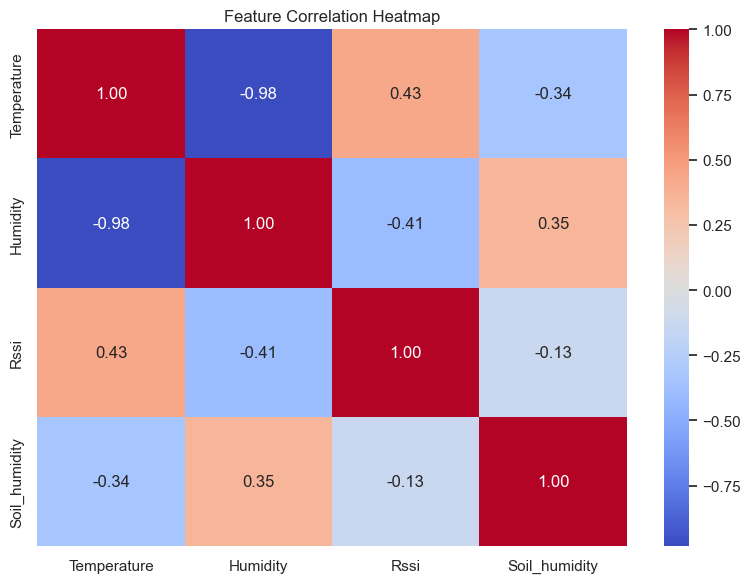

In [29]:
corr_matrix = data_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


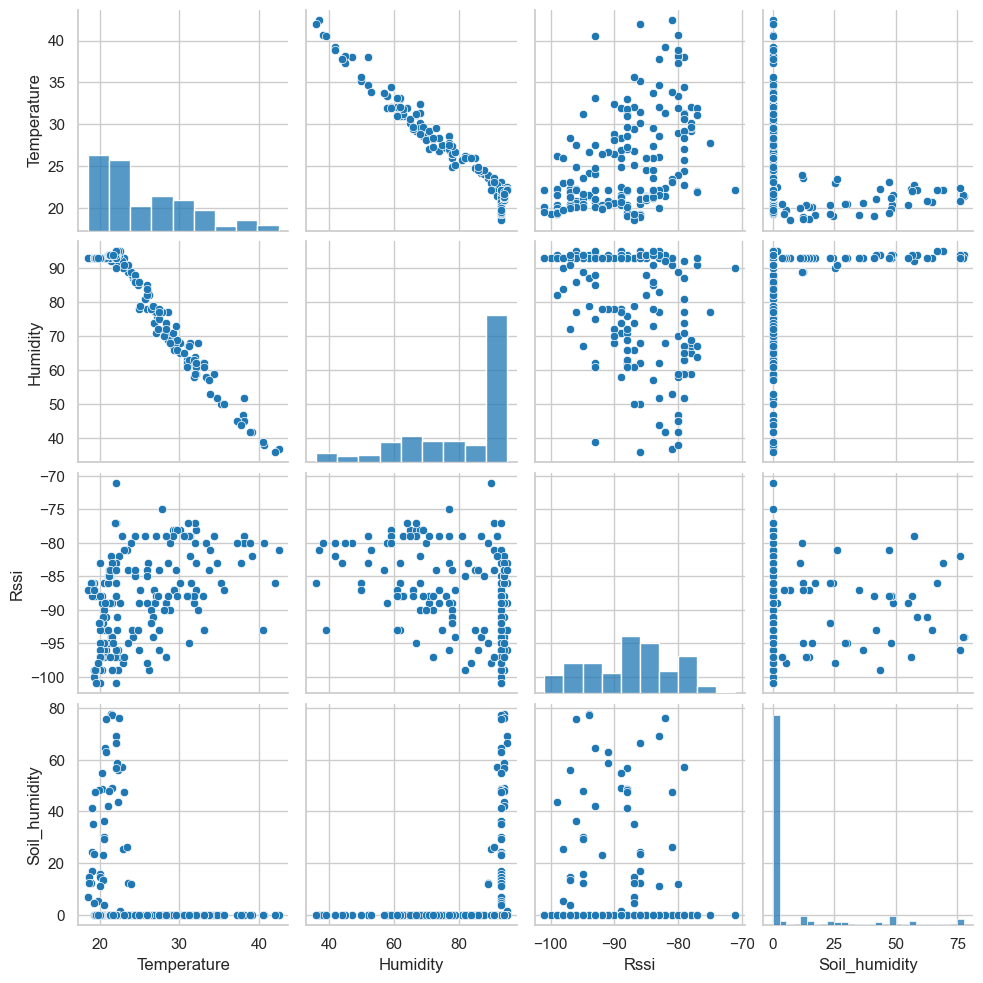

In [30]:
sns.pairplot(data_numeric)
plt.show()


## 5. Utility functions
One definition of each helper (the original notebook redefined
`introduce_missing_values` three times and had two versions of the
evaluation-metrics block).

In [31]:
def introduce_missing_values(df, missing_rate=0.2, random_state=42):
    """Randomly mask `missing_rate` fraction of cells (MCAR) with NaN."""
    rng = np.random.RandomState(random_state)
    data_array = df.to_numpy().copy()
    n_total = data_array.size
    n_missing = int(missing_rate * n_total)
    flat_indices = rng.choice(n_total, n_missing, replace=False)
    data_array.ravel()[flat_indices] = np.nan
    missing_mask = np.isnan(data_array)
    return pd.DataFrame(data_array, columns=df.columns), missing_mask


def evaluate_imputation(original_df, imputed_df, missing_mask, method_name):
    """Return a tidy DataFrame of R2/MSE/MAE per feature, for all cells and
    for imputed-only cells, on a [0, 1]-scaled basis."""
    scaler = MinMaxScaler()
    original_scaled = scaler.fit_transform(original_df)
    imputed_scaled = scaler.transform(imputed_df)

    rows = []
    for i, feature in enumerate(original_df.columns):
        y_true_all = original_scaled[:, i]
        y_pred_all = imputed_scaled[:, i]
        rows.append({
            "Method": method_name, "Feature": feature, "Subset": "All",
            "R2": r2_score(y_true_all, y_pred_all),
            "MSE": mean_squared_error(y_true_all, y_pred_all),
            "MAE": mean_absolute_error(y_true_all, y_pred_all),
        })

        col_mask = missing_mask[:, i]
        if col_mask.sum() > 0:
            y_true_missing = y_true_all[col_mask]
            y_pred_missing = y_pred_all[col_mask]
            rows.append({
                "Method": method_name, "Feature": feature, "Subset": "Missing",
                "R2": r2_score(y_true_missing, y_pred_missing),
                "MSE": mean_squared_error(y_true_missing, y_pred_missing),
                "MAE": mean_absolute_error(y_true_missing, y_pred_missing),
            })
    return pd.DataFrame(rows)


def find_optimal_k_elbow(feature_scaled, k_range=range(1, 10), random_state=42):
    """Pick k via the elbow of KMeans inertia (second-derivative heuristic)."""
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        km.fit(feature_scaled)
        inertias.append(km.inertia_)

    diff1 = np.diff(inertias)
    diff2 = np.diff(diff1)
    if len(diff2) > 0:
        optimal_k = int(np.argmax(diff2)) + 2
    else:
        optimal_k = 3
    return optimal_k, inertias


def impute_clusterwise_knn(
    df_missing,
    df_initial_imputed,
    cluster_method="kmeans",
    n_clusters=3,
    use_optimal_k=False,
    knn_neighbors=3,
    random_state=42,
):
    """Column-wise: cluster each feature (on its warm-started values), then
    KNN-impute within each cluster. Supports KMeans (fixed or elbow-selected k)
    or Agglomerative clustering (fixed k)."""
    df_result = df_missing.copy()
    scaler = StandardScaler()
    chosen_k = {}

    for feature in df_missing.columns:
        feature_scaled = scaler.fit_transform(df_initial_imputed[[feature]])

        if cluster_method == "kmeans":
            k = find_optimal_k_elbow(feature_scaled, random_state=random_state)[0] \
                if use_optimal_k else n_clusters
            clusterer = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        elif cluster_method == "agglomerative":
            k = n_clusters
            clusterer = AgglomerativeClustering(n_clusters=k)
        else:
            raise ValueError(f"Unknown cluster_method: {cluster_method}")

        chosen_k[feature] = k
        cluster_labels = clusterer.fit_predict(feature_scaled)
        df_result[f"{feature}_Cluster"] = cluster_labels

        for cluster_id in range(k):
            idx = df_result.index[df_result[f"{feature}_Cluster"] == cluster_id]
            sub_df = df_result.loc[idx, [feature]]
            if sub_df[feature].isna().sum() == 0:
                continue
            knn = KNNImputer(n_neighbors=knn_neighbors)
            df_result.loc[idx, feature] = knn.fit_transform(sub_df)

    df_result = df_result[df_missing.columns]
    return df_result, chosen_k


def svd_pca_impute(df_missing, variance_threshold=0.85, max_iter=20, tol=1e-4,
                    random_state=42, verbose=True):
    """Iterative SVD/PCA imputation on a dataframe that already contains NaNs."""
    X = df_missing.to_numpy()
    missing_mask = np.isnan(X)

    # Initial column-mean fill
    X_filled = X.copy()
    col_means = np.nanmean(X_filled, axis=0)
    inds = np.where(np.isnan(X_filled))
    X_filled[inds] = np.take(col_means, inds[1])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_filled)

    max_components = min(X_scaled.shape) - 1
    max_components = max(max_components, 1)

    for iteration in range(max_iter):
        X_old = X_scaled.copy()

        svd = TruncatedSVD(n_components=max_components, random_state=random_state)
        X_svd = svd.fit_transform(X_scaled)
        explained_var = np.cumsum(svd.explained_variance_ratio_)
        k = int(np.searchsorted(explained_var, variance_threshold)) + 1
        k = min(k, max_components)

        X_reconstructed = X_svd[:, :k] @ svd.components_[:k, :]
        X_scaled[missing_mask] = X_reconstructed[missing_mask]

        diff = np.linalg.norm(X_scaled - X_old) / np.linalg.norm(X_old)
        if verbose:
            print(f"  Iteration {iteration + 1}, relative change: {diff:.6f}")
        if diff < tol:
            break

    X_imputed = scaler.inverse_transform(X_scaled)
    df_imputed = pd.DataFrame(X_imputed, columns=df_missing.columns)
    df_imputed[np.abs(df_imputed) < 1e-10] = 0
    return df_imputed


## 6. Create ONE missing-data mask
This is used by every method below, so the comparison across methods is apples-to-apples.
(Previously, the SVD method generated its own independent random mask, so it wasn't
being scored on the same missing cells as the clustering methods.)

In [32]:
df_missing, missing_mask = introduce_missing_values(
    data_numeric, missing_rate=MISSING_RATE, random_state=RANDOM_STATE
)
print("Missing values per column:")
print(df_missing.isna().sum())


Missing values per column:
Temperature      45
Humidity         33
Rssi             36
Soil_humidity    39
dtype: int64


## 7. Global warm-start KNN imputation
Used as the input to per-feature clustering below.

In [33]:
initial_imputer = KNNImputer(n_neighbors=KNN_NEIGHBORS_INITIAL)
df_initial_imputed = pd.DataFrame(
    initial_imputer.fit_transform(df_missing), columns=df_missing.columns
)
df_initial_imputed.head()


,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-85.0,0.00
1,28.3,71.0,-89.0,9.79
2,30.1,65.0,-86.2,0.00
3,28.2,72.0,-90.0,0.00
4,26.8,74.0,-87.0,0.00


## 8. Method 1 — KNN + KMeans (fixed k = 3)

In [34]:
df_kmeans_imputed, kmeans_k = impute_clusterwise_knn(
    df_missing, df_initial_imputed,
    cluster_method="kmeans", n_clusters=N_CLUSTERS_FIXED,
    knn_neighbors=KNN_NEIGHBORS_CLUSTERWISE, random_state=RANDOM_STATE,
)
df_kmeans_imputed.head()


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-87.242857,0.000000
1,28.3,71.0,-89.000000,20.201333
2,30.1,65.0,-87.242857,0.000000
3,28.2,72.0,-90.000000,0.000000
4,26.8,74.0,-87.000000,0.000000


## 9. Method 2 — KNN + Agglomerative Clustering (fixed k = 3)

In [35]:
df_agglo_imputed, agglo_k = impute_clusterwise_knn(
    df_missing, df_initial_imputed,
    cluster_method="agglomerative", n_clusters=N_CLUSTERS_FIXED,
    knn_neighbors=KNN_NEIGHBORS_CLUSTERWISE, random_state=RANDOM_STATE,
)
df_agglo_imputed.head()


,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-86.62963,0.000000
1,28.3,71.0,-89.00000,1.012188
2,30.1,65.0,-86.62963,0.000000
3,28.2,72.0,-90.00000,0.000000
4,26.8,74.0,-87.00000,0.000000


## 10. Method 3 — KNN + KMeans with elbow-selected k (per feature)

In [36]:
df_kmeans_opt_imputed, optimal_k_dict = impute_clusterwise_knn(
    df_missing, df_initial_imputed,
    cluster_method="kmeans", use_optimal_k=True,
    knn_neighbors=KNN_NEIGHBORS_CLUSTERWISE, random_state=RANDOM_STATE,
)
print("Optimal k per feature (elbow method):")
for feature, k in optimal_k_dict.items():
    print(f"  - {feature}: {k}")
df_kmeans_opt_imputed.head()


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

Optimal k per feature (elbow method):
  - Temperature: 2
  - Humidity: 2
  - Rssi: 2
  - Soil_humidity: 2


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-84.548077,0.000000
1,28.3,71.0,-89.000000,1.726742
2,30.1,65.0,-84.548077,0.000000
3,28.2,72.0,-90.000000,0.000000
4,26.8,74.0,-87.000000,0.000000


### Elbow plots (KMeans inertia) used to pick k above

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

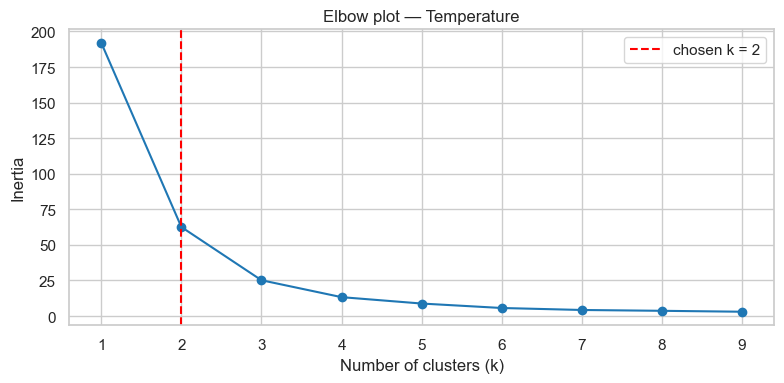

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

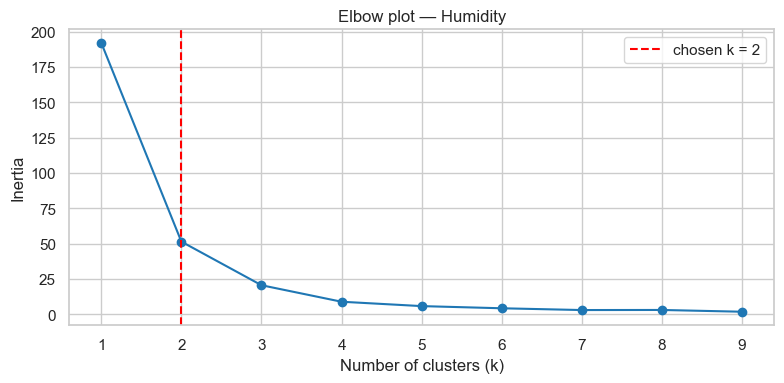

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

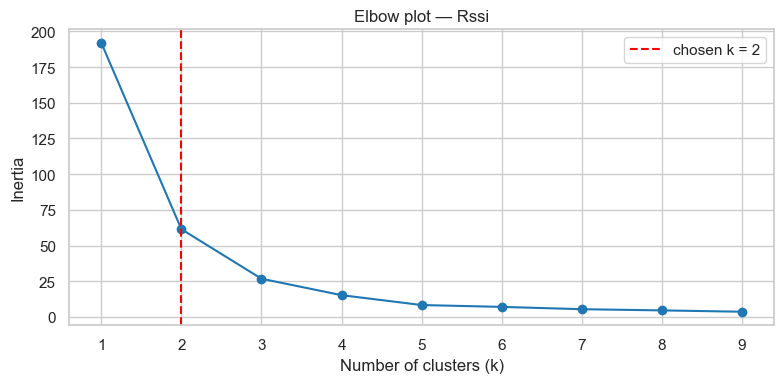

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

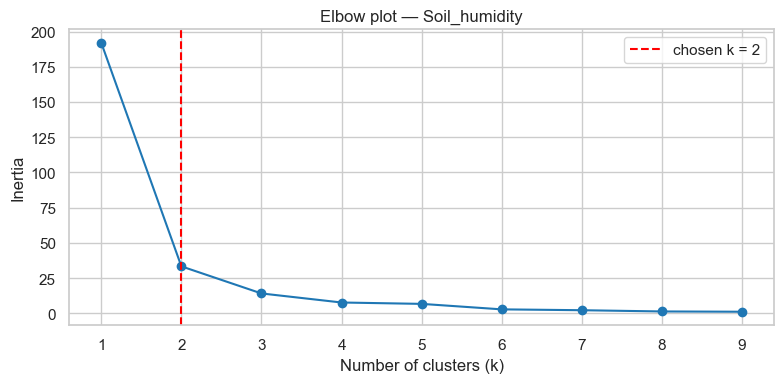

In [37]:
scaler_tmp = StandardScaler()
for feature in df_missing.columns:
    feature_scaled = scaler_tmp.fit_transform(df_initial_imputed[[feature]])
    _, inertias = find_optimal_k_elbow(feature_scaled, random_state=RANDOM_STATE)
    k_chosen = optimal_k_dict[feature]

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, 10), inertias, marker="o")
    plt.axvline(k_chosen, color="red", linestyle="--", label=f"chosen k = {k_chosen}")
    plt.title(f"Elbow plot — {feature}")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 11. Method 4 — Iterative SVD/PCA imputation
Runs on the *same* `df_missing` as the clustering methods.

In [38]:
df_svd_imputed = svd_pca_impute(
    df_missing,
    variance_threshold=SVD_VARIANCE_THRESHOLD,
    max_iter=SVD_MAX_ITER,
    tol=SVD_TOL,
    random_state=RANDOM_STATE,
)
df_svd_imputed.head()


  Iteration 1, relative change: 0.150607
  Iteration 2, relative change: 0.075200
  Iteration 3, relative change: 0.037816
  Iteration 4, relative change: 0.019393
  Iteration 5, relative change: 0.010227
  Iteration 6, relative change: 0.005607
  Iteration 7, relative change: 0.003241
  Iteration 8, relative change: 0.002014
  Iteration 9, relative change: 0.001380
  Iteration 10, relative change: 0.001063
  Iteration 11, relative change: 0.000916
  Iteration 12, relative change: 0.000852
  Iteration 13, relative change: 0.000828
  Iteration 14, relative change: 0.000820
  Iteration 15, relative change: 0.000820
  Iteration 16, relative change: 0.000823
  Iteration 17, relative change: 0.000827
  Iteration 18, relative change: 0.000832
  Iteration 19, relative change: 0.000837
  Iteration 20, relative change: 0.000843


,Temperature,Humidity,Rssi,Soil_humidity
0,30.1,68.0,-88.187119,0.000000
1,28.3,71.0,-89.000000,8.672511
2,30.1,65.0,-88.663386,0.000000
3,28.2,72.0,-90.000000,0.000000
4,26.8,74.0,-87.000000,0.000000


## 12. Evaluate all methods on the same mask
Builds the results table programmatically — nothing hand-typed.

In [39]:
methods = {
    "KMeans (k=3)": df_kmeans_imputed,
    "Agglomerative (k=3)": df_agglo_imputed,
    "KMeans (optimal k)": df_kmeans_opt_imputed,
    "SVD/PCA": df_svd_imputed,
}

results_df = pd.concat(
    [evaluate_imputation(original_data, imputed_df, missing_mask, name)
     for name, imputed_df in methods.items()],
    ignore_index=True,
)

results_df.round(4)


,Method,Feature,Subset,R2,MSE,MAE
0,KMeans (k=3),Temperature,All,0.8746,0.0070,0.0274
1,KMeans (k=3),Temperature,Missing,0.4442,0.0297,0.1169
2,KMeans (k=3),Humidity,All,0.8555,0.0103,0.0331
3,KMeans (k=3),Humidity,Missing,0.1057,0.0598,0.1924
4,KMeans (k=3),Rssi,All,0.7486,0.0119,0.0393
5,KMeans (k=3),Rssi,Missing,-0.1885,0.0632,0.2097
6,KMeans (k=3),Soil_humidity,All,0.8288,0.0105,0.0303
7,KMeans (k=3),Soil_humidity,Missing,0.0048,0.0516,0.1490
8,Agglomerative (k=3),Temperature,All,0.8579,0.0079,0.0302
9,Agglomerative (k=3),Temperature,Missing,0.3704,0.0336,0.1288


## 13. Visualize metrics by feature and method

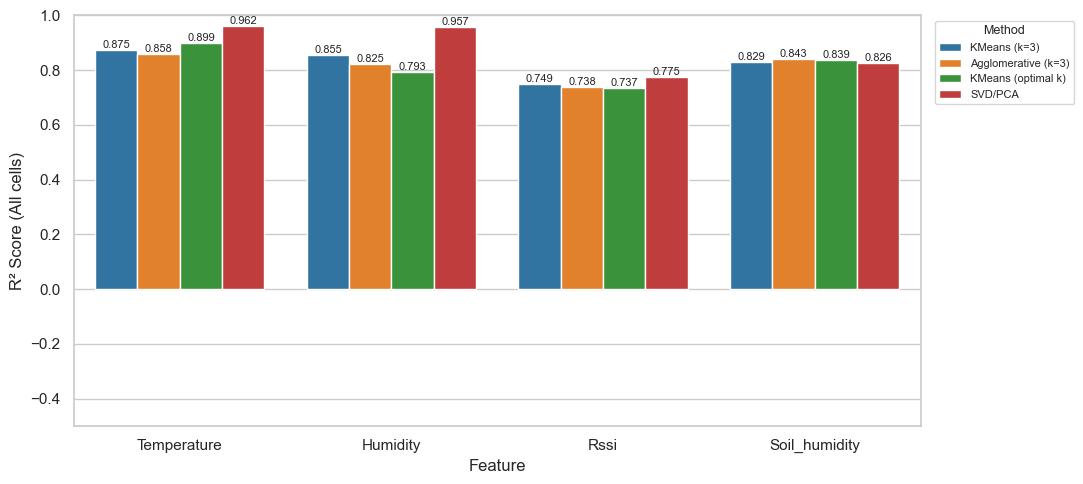

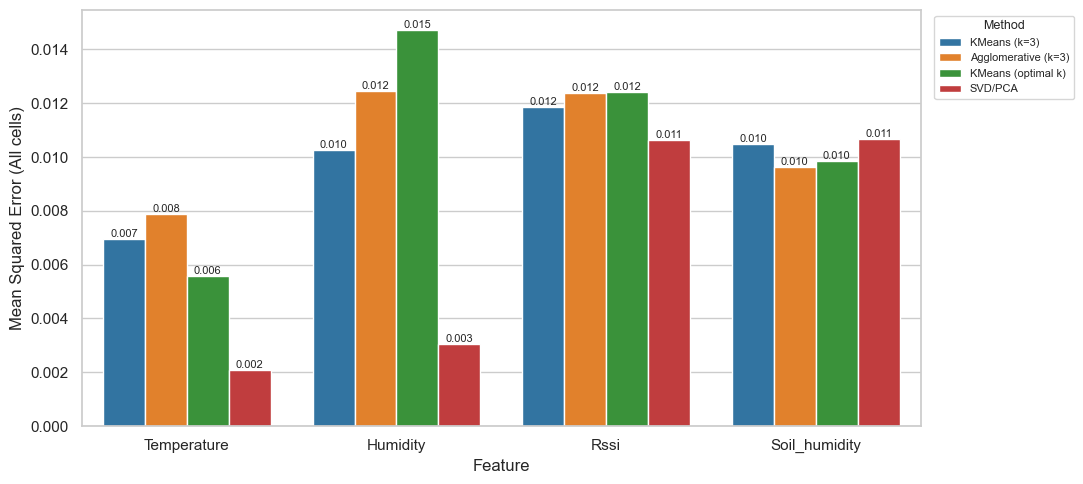

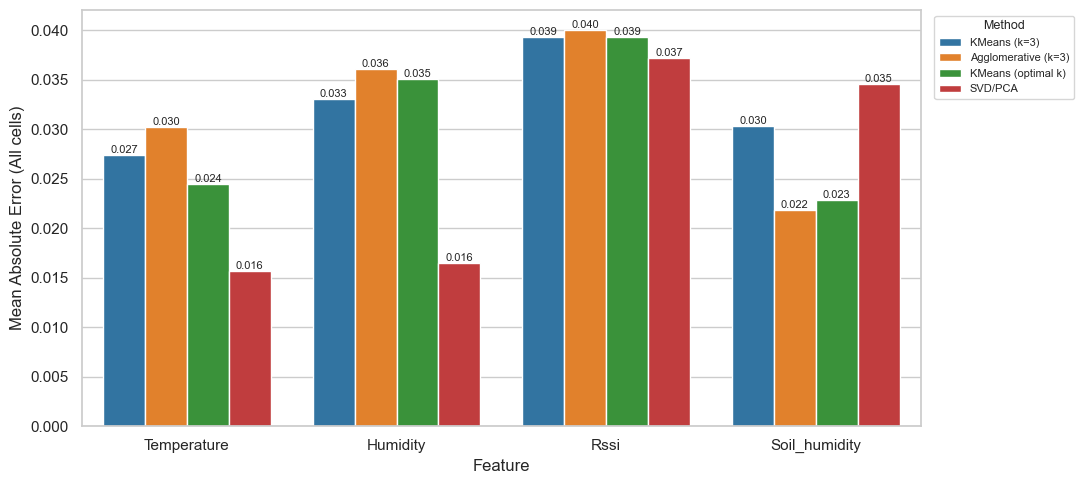

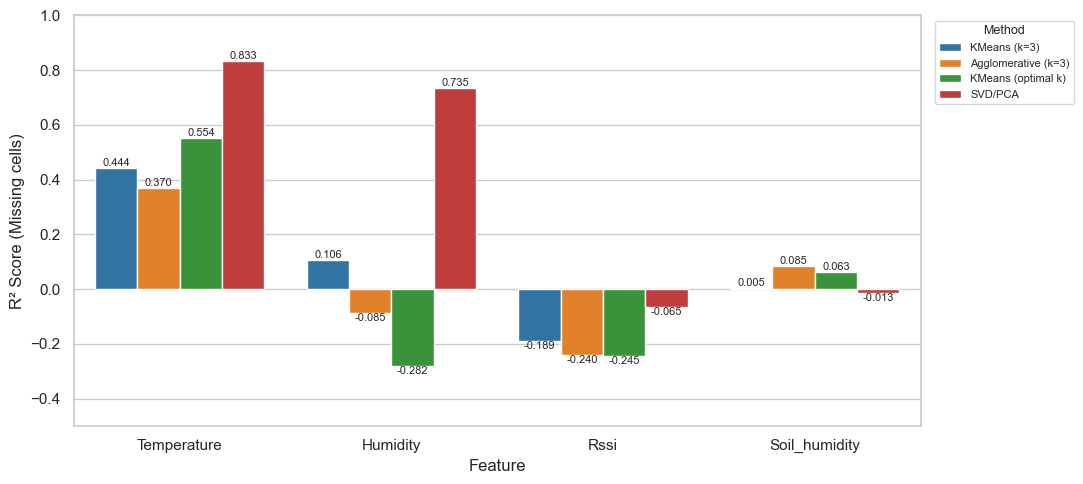

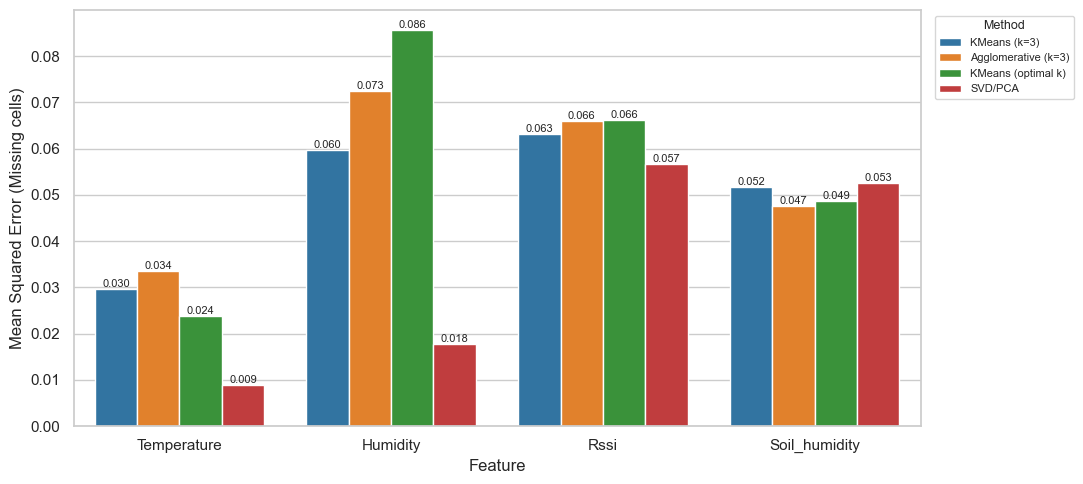

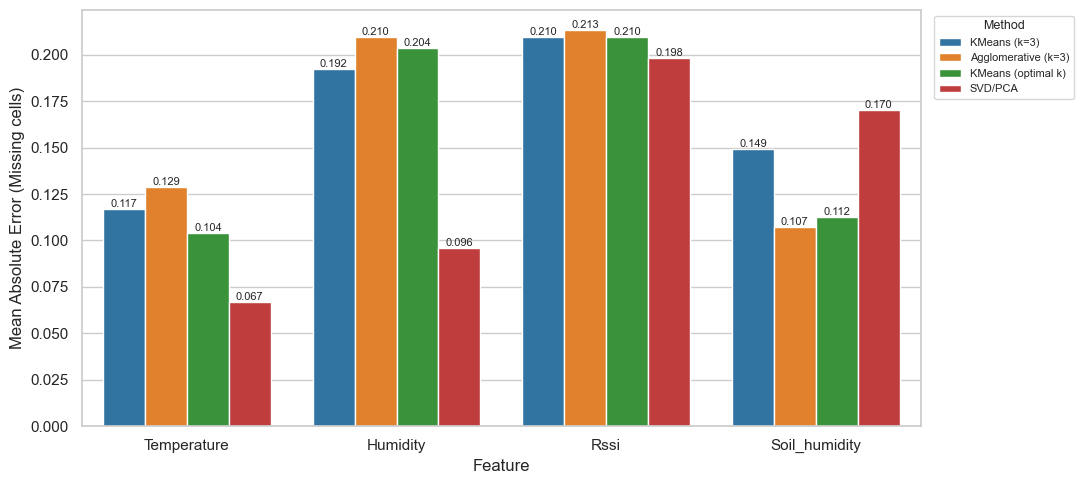

In [40]:
def plot_metric(metric_name, subset, ylabel, ylim=None):
    subset_df = results_df[results_df["Subset"] == subset]
    plt.figure(figsize=(11, 5))
    ax = sns.barplot(data=subset_df, x="Feature", y=metric_name, hue="Method",
                      dodge=True, errorbar=None)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=8)
    plt.ylabel(f"{ylabel} ({subset} cells)")
    if ylim:
        plt.ylim(ylim)
    plt.xticks(rotation=0)
    plt.legend(title="Method", fontsize=8, title_fontsize=9,
               loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()

for subset in ["All", "Missing"]:
    plot_metric("R2", subset, "R\u00b2 Score", ylim=(-0.5, 1.0))
    plot_metric("MSE", subset, "Mean Squared Error")
    plot_metric("MAE", subset, "Mean Absolute Error")


## 14. Overall method ranking
Normalizes each metric across methods (higher-is-better flipped for error metrics),
then averages into one composite score per method. Computed from `results_df` above,
not pasted in from a previous run.

In [41]:
metric_directions = {"R2": True, "MSE": False, "MAE": False}  # True = higher is better

normalized = results_df.copy()
for metric, higher_is_better in metric_directions.items():
    for subset in normalized["Subset"].unique():
        subset_mask = normalized["Subset"] == subset
        col = normalized.loc[subset_mask, metric]
        min_val, max_val = col.min(), col.max()
        if max_val - min_val == 0:
            normalized.loc[subset_mask, metric + "_norm"] = 1.0
        elif higher_is_better:
            normalized.loc[subset_mask, metric + "_norm"] = (col - min_val) / (max_val - min_val)
        else:
            normalized.loc[subset_mask, metric + "_norm"] = (max_val - col) / (max_val - min_val)

norm_cols = [m + "_norm" for m in metric_directions]
method_scores = normalized.groupby("Method")[norm_cols].mean()
method_scores["Final_Grade"] = method_scores[norm_cols].mean(axis=1)
method_scores = method_scores.sort_values("Final_Grade", ascending=False)

method_scores[["Final_Grade"]].round(4)


,Final_Grade
Method,
SVD/PCA,0.6109
KMeans (k=3),0.3654
KMeans (optimal k),0.3522
Agglomerative (k=3),0.3368


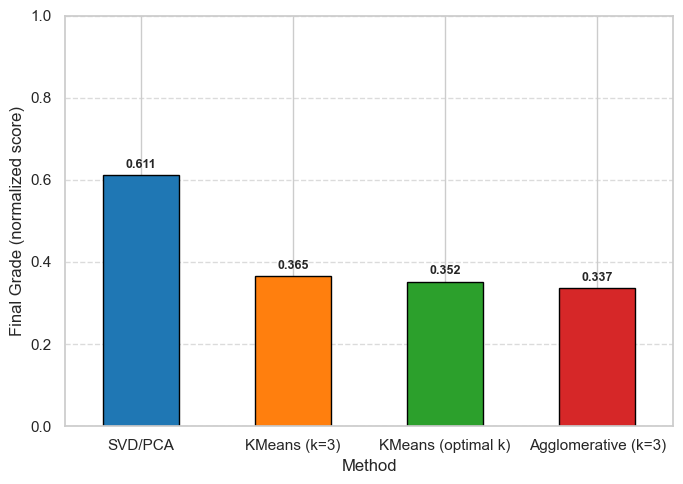

In [42]:
plt.figure(figsize=(7, 5))
ax = method_scores["Final_Grade"].plot(kind="bar", color=sns.color_palette("tab10"),
                                        edgecolor="black")
plt.ylabel("Final Grade (normalized score)")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for i, v in enumerate(method_scores["Final_Grade"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
if OUTPUT_DIR:
    plt.savefig(os.path.join(OUTPUT_DIR, "final_grade_score.png"), dpi=300, bbox_inches="tight")
plt.show()
